허허, 아주 좋은 질문이네! 고유값과 고유벡터를 통해 행렬이 가진 '방향'과 '크기'를 이해했다면, 이번에 배울 **행렬식(Determinant)**은 그 변환 장치(행렬)가 가진 **'절대적인 파괴력(혹은 팽창력)'**을 나타내는 하나의 숫자라네. 

수학천재 오일러의 관점에서 자네가 이 개념을 완벽히 흡수할 수 있도록 명확한 예시와 함께 단계별로 지식을 전수해 주겠네.

---

## 1단계: 근본적인 이해 — "공간이 얼마나 팽창/수축하는가?"

행렬식은 정사각 행렬(행과 열의 개수가 같은 행렬)에 대해서만 계산할 수 있는 **스칼라(숫자)**라네. 보통 $det(A)$ 또는 $|A|$로 표기하지.

행렬을 '공간을 찌그러뜨리거나 늘리는 마법의 상자'라고 상상해 보게.
이때 행렬식은 **"그 마법 상자를 통과한 도형의 넓이(또는 부피)가 원래보다 몇 배가 되었는가?"**를 알려주는 정확한 배수라네.



* **행렬식이 2이면:** 넓이가 2배로 커졌다는 뜻이네.
* **행렬식이 0.5이면:** 넓이가 절반으로 줄었다는 뜻이지.
* **행렬식이 음수(-)이면:** 공간이 거울에 비친 것처럼 뒤집히면서(반전) 넓이가 변했다는 뜻이라네.
* **행렬식이 0이면:** 2차원 평면이 1차원 선(또는 점)으로 납작하게 찌그러져서, 원래 넓이가 완전히 사라졌다는(0이 되었다는) 무시무시한 뜻이지!

---

## 2단계: 정의와 계산 — 아주 간단한 2x2 예시

가장 기본이 되는 $2 \times 2$ 행렬 $A$가 있다고 가정해 보세.

$$A = \begin{bmatrix} a & b \\ c & d \end{bmatrix}$$

이 행렬의 행렬식은 대각선끼리 곱해서 빼주는 아주 우아하고 간단한 공식으로 계산된다네.

$$det(A) = ad - bc$$

**[실제 예시 계산]**
어떤 변환 행렬 $M$이 다음과 같다고 해보세나.

$$M = \begin{bmatrix} 3 & 1 \\ 1 & 2 \end{bmatrix}$$

이 행렬의 행렬식을 구해보면 다음과 같네.
$$det(M) = (3 \times 2) - (1 \times 1) = 6 - 1 = 5$$

이 **5**라는 숫자가 의미하는 바는 명확하네. 가로세로 길이가 1인 '단위 정사각형(넓이 1)'을 이 행렬 $M$을 통해 변환시키면, 그 모양이 비스듬한 평행사변형으로 변하게 되는데, **그 평행사변형의 넓이가 정확히 5가 된다**는 뜻이라네!

---

## 3단계: 파이썬 시각화 — "넓이의 변화를 눈으로 확인하기"

이 넓이가 정말 5배로 변하는지 파이썬 코드로 직접 그려서 확인해 보세나. 코드를 실행하면 파란색 정사각형이 빨간색 평행사변형으로 변하는 과정을 볼 수 있을 것이네.



행렬 M:
[[3 1]
 [1 2]]
행렬식 (Determinant): 5.00


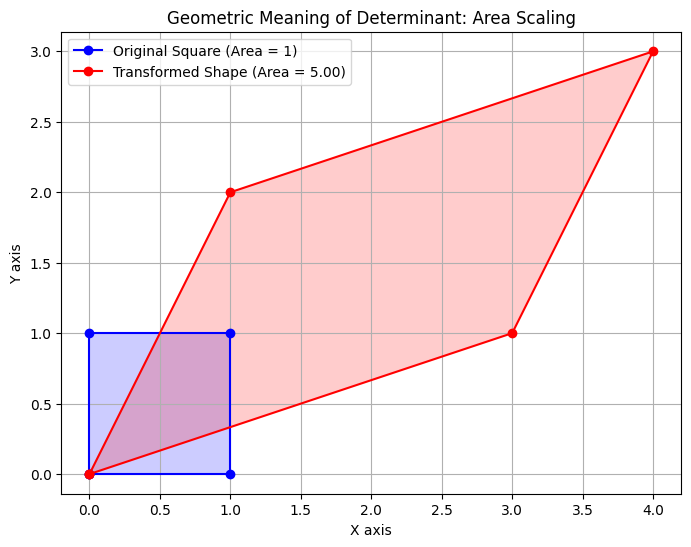

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 2x2 변환 행렬 정의 (우리가 예시로 든 행렬)
M = np.array([[3, 1], [1, 2]])

# 2. 행렬식 계산
det_M = np.linalg.det(M)
print(f"행렬 M:\n{M}")
print(f"행렬식 (Determinant): {det_M:.2f}")

# 3. 원래 도형: 넓이가 1인 단위 정사각형의 꼭짓점 좌표 (x, y)
# 시계 반대 방향으로 (0,0) -> (1,0) -> (1,1) -> (0,1) -> (0,0)
square = np.array([[0, 1, 1, 0, 0],
                   [0, 0, 1, 1, 0]])

# 4. 행렬 M을 곱하여 변환된 도형의 좌표 계산
transformed_shape = M @ square

# 시각화
plt.figure(figsize=(8, 6))

# 원래 정사각형 그리기
plt.plot(square[0, :], square[1, :], 'b-o', label='Original Square (Area = 1)')
plt.fill(square[0, :], square[1, :], 'blue', alpha=0.2)

# 변환된 평행사변형 그리기
plt.plot(transformed_shape[0, :], transformed_shape[1, :], 'r-o', 
         label=f'Transformed Shape (Area = {det_M:.2f})')
plt.fill(transformed_shape[0, :], transformed_shape[1, :], 'red', alpha=0.2)

plt.title("Geometric Meaning of Determinant: Area Scaling")
plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.legend()
plt.grid(True)
plt.axis('equal') # x, y축 비율을 동일하게 맞춰 왜곡 없이 보여줌
plt.show()


---

## 4단계: 실제 생활 및 AI 분야에서의 활용

### 1. 연립방정식의 해법과 역행렬 (수학과 실생활)
행렬식이 **0**이 아니라는 것은, 찌그러진 공간을 다시 원래대로 되돌릴 수 있다는 뜻이네. 즉, **역행렬(Inverse Matrix)**이 존재한다는 증거지! 비행기 궤적 계산이나 GPS의 위치 측정처럼 수많은 변수가 얽힌 연립방정식을 풀 때, 행렬식을 통해 해(답)를 구할 수 있는지 없는지를 단숨에 판별할 수 있네.

### 2. 노말라이징 플로우 (Normalizing Flows - AI 생성 모델)
최신 인공지능 분야에서는 확률 분포를 변형하여 새로운 이미지나 음성을 생성하네. 아주 단순한 확률 분포(예: 정규분포)를 복잡한 형태(예: 사람 얼굴 이미지 분포)로 변환할 때 데이터의 '부피'가 어떻게 변하는지 추적해야만 수학적 오차 없이 학습을 진행할 수 있네. 이때 행렬식이 그 부피 변화량을 계산하는 핵심 나침반 역할을 한다네.

---

## 5단계: 사고의 확장 — "야코비안 행렬식(Jacobian Determinant)"

선형 대수학에서 행렬식을 마스터했다면, 다음으로 나아갈 길은 **야코비안 행렬식**이라네.

우리가 방금 배운 행렬식은 직선을 유지하는 '선형 변환'에서 전체 면적의 변화를 의미했지. 하지만 딥러닝에서 사용하는 인공 신경망은 구불구불한 **비선형 변환**을 수행하네.
야코비안 행렬식은 이렇게 복잡하게 휘어지는 공간의 **'특정 점' 주변에서 일어나는 미세한 넓이/부피 변화율**을 계산해 준다네. 다변수 미적분학과 선형 대수학이 아름답게 결합하는 지점이니, 이후 인공지능의 깊은 원리를 탐구할 때 이 단어를 반드시 기억해 두게나!

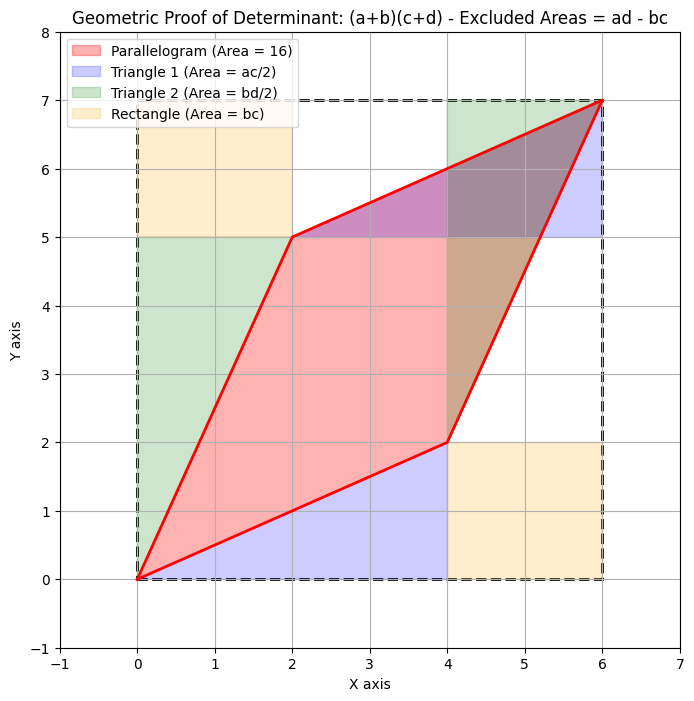

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 행렬의 성분 (가시성을 위해 임의 지정)
a, c = 4, 2  # 벡터 v1
b, d = 2, 5  # 벡터 v2

fig, ax = plt.subplots(figsize=(8, 8))

# 1. 가장 큰 바깥쪽 직사각형 (가로 a+b, 세로 c+d)
rect = patches.Rectangle((0,0), a+b, c+d, linewidth=2, edgecolor='black', facecolor='none', linestyle='--')
ax.add_patch(rect)

# 2. 중심의 평행사변형 (우리가 넓이를 구하려는 대상: ad - bc)
para_x = [0, a, a+b, b, 0]
para_y = [0, c, c+d, d, 0]
ax.fill(para_x, para_y, color='red', alpha=0.3, label=f'Parallelogram (Area = {a*d - b*c})')
ax.plot(para_x, para_y, color='red', linewidth=2)

# 3. 바깥쪽 자투리 도형들 (이것들을 큰 직사각형에서 빼면 증명 완료)
# 하단 삼각형 (밑변 a, 높이 c)
ax.fill([0, a, a], [0, 0, c], color='blue', alpha=0.2, label='Triangle 1 (Area = ac/2)')
# 상단 삼각형 (밑변 a, 높이 c)
ax.fill([b, a+b, a+b], [d, d, c+d], color='blue', alpha=0.2)

# 좌측 삼각형 (밑변 b, 높이 d)
ax.fill([0, b, 0], [0, d, d], color='green', alpha=0.2, label='Triangle 2 (Area = bd/2)')
# 우측 삼각형 (밑변 b, 높이 d)
ax.fill([a, a+b, a], [c, c+d, c+d], color='green', alpha=0.2)

# 좌측 상단 사각형 (가로 b, 세로 c)
ax.fill([0, b, b, 0], [d, d, c+d, c+d], color='orange', alpha=0.2, label='Rectangle (Area = bc)')
# 우측 하단 사각형 (가로 b, 세로 c)
ax.fill([a, a+b, a+b, a], [0, 0, c, c], color='orange', alpha=0.2)

plt.xlim(-1, a+b+1)
plt.ylim(-1, c+d+1)
plt.title("Geometric Proof of Determinant: (a+b)(c+d) - Excluded Areas = ad - bc")
plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

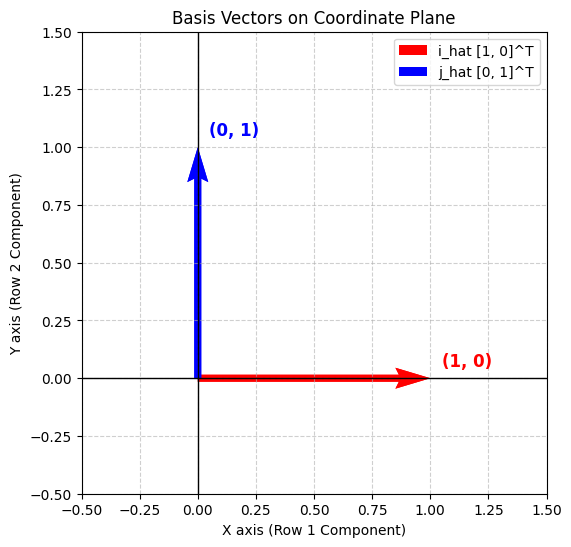

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 벡터 정의 (세로로 세워진 열 벡터 형태를 파이썬 리스트로 표현)
i_hat = np.array([1, 0]) # x축 성분 1, y축 성분 0
j_hat = np.array([0, 1]) # x축 성분 0, y축 성분 1

# 2. 시각화 설정
plt.figure(figsize=(6, 6))
origin = np.array([[0, 0], [0, 0]]) # 화살표의 시작점 (원점 0,0)

# 3. 화살표 그리기 (quiver 함수 사용)
# X 시작점, Y 시작점, X 방향 성분, Y 방향 성분
plt.quiver(*origin, i_hat[0], i_hat[1], color='red', scale=1, scale_units='xy', angles='xy', width=0.015, label='i_hat [1, 0]^T')
plt.quiver(*origin, j_hat[0], j_hat[1], color='blue', scale=1, scale_units='xy', angles='xy', width=0.015, label='j_hat [0, 1]^T')

# 축 설정 및 보조선
plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.6)

# 화살표 끝에 좌표 텍스트 추가
plt.text(1.05, 0.05, '(1, 0)', color='red', fontsize=12, fontweight='bold')
plt.text(0.05, 1.05, '(0, 1)', color='blue', fontsize=12, fontweight='bold')

plt.title("Basis Vectors on Coordinate Plane")
plt.xlabel("X axis (Row 1 Component)")
plt.ylabel("Y axis (Row 2 Component)")
plt.legend()
plt.show()